## Spectral Analysis - Project

### Imports

In [1]:
import numpy as np
import pyroomacoustics as pra
import matplotlib.pyplot as plt
from scipy.linalg import eig

from numpy.fft import irfft
import soundfile as sf

import scipy.io.wavfile as wav

### Defining the Room

Defining the room dimensions and placement of both speakers and microphones.

In [2]:
# Some variables that can be changed

nbr_bounces = 3
air_absorption = True

fs = 16000   # Sampling freq. of the played audio
room_dim = [5.0, 5.0, 5.0]

num_speakers_per_row = 10

(<Figure size 640x480 with 1 Axes>, <Axes3D: >)

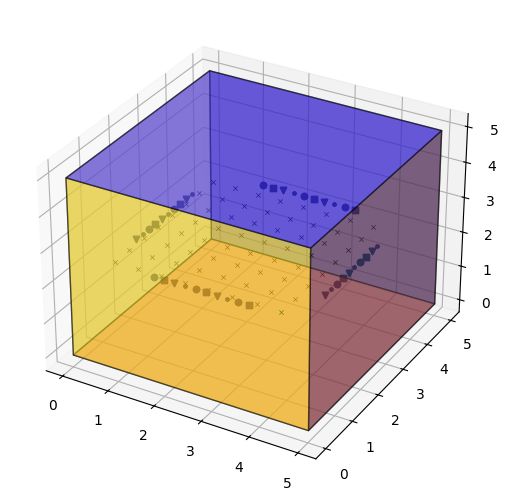

In [3]:
room = pra.ShoeBox(room_dim, fs=fs, max_order=nbr_bounces, air_absorption=air_absorption)

# max_order: max number of reflections in the room
# air_absorbtion: if air is absorbed or not

# Speakers
if False:
    # A 5-speaker linear array
    num_speakers = 10
    speaker_x = np.linspace(1.5, 3.5, num_speakers)
    speaker_locs = np.vstack((speaker_x, np.full(num_speakers, 0.5), np.full(num_speakers, 2.5)))

    for loc in speaker_locs.T:
        room.add_source(loc)
if True:
    # Define coordinates for microphones on all 4 walls (Front, Right, Back, Left)
    speaker_x = np.linspace(1.5, 3.5, num_speakers_per_row)
    speaker_locs_front = np.vstack((speaker_x, np.full(num_speakers_per_row, 0.5), np.full(num_speakers_per_row, 2.5)))
    speaker_locs_right = np.vstack((np.full(num_speakers_per_row, 4.5), speaker_x, np.full(num_speakers_per_row, 2.5)))
    speaker_locs_back  = np.vstack((speaker_x, np.full(num_speakers_per_row, 4.5), np.full(num_speakers_per_row, 2.5)))
    speaker_locs_left  = np.vstack((np.full(num_speakers_per_row, 0.5), speaker_x, np.full(num_speakers_per_row, 2.5)))

    # Combine all 4 arrays into one master speaker list
    all_speakers = np.hstack((speaker_locs_front, speaker_locs_right, speaker_locs_back, speaker_locs_left))

    num_speakers = all_speakers.shape[1]
    # Add all 40 speakers to the room
    for loc in all_speakers.T:
        room.add_source(loc)

# Microphone Grid
spacing = 0.5
x_coords = np.arange(0.6, 4.4, spacing)
y_coords = np.arange(0.6, 4.4, spacing)
X, Y = np.meshgrid(x_coords, y_coords)
mics_locs = np.vstack((X.flatten(), Y.flatten(), np.full(X.size, 2.5)))
num_mics = mics_locs.shape[1]    # The total number of microphones. Used later
mic_array = pra.MicrophoneArray(mics_locs, room.fs)
room.add_microphone_array(mic_array)

# Plotting
room.plot()

### Room Impulse Response

Calculating the room impulse response (RIR)  $h_{s,m}(t)$ for each combination of speaker $s$ and microphone $m$.

In [4]:
nfft = 512*2      # The number of frequency grid points we want to have

print('Computing RIR...')
room.compute_rir()

# A 3D matrix to save the fft of each RIR
print('Computing H...')
H_full = np.zeros((num_mics, num_speakers, nfft//2 + 1), dtype=complex)    # All zeros in the beginning
for m in range(num_mics):
    for s in range(num_speakers):
        H_full[m, s, :] = np.fft.rfft(room.rir[m][s], n=nfft)
f_axis = np.fft.rfftfreq(nfft, d=1/fs)

Computing RIR...
Computing H...


### Creating a monotone sound

In [5]:
# These attributes can be changed to create a signal of your choice

audio_freq = np.array([500, 2000])
audio_amp = 1
audio_amp = np.array([1, 2])
audio_phase = 0
audio_phase = np.array([np.pi, np.pi/2])

duration = 2.0  # seconds

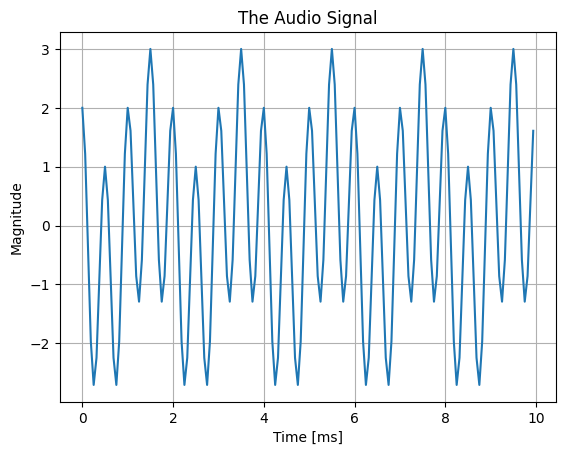

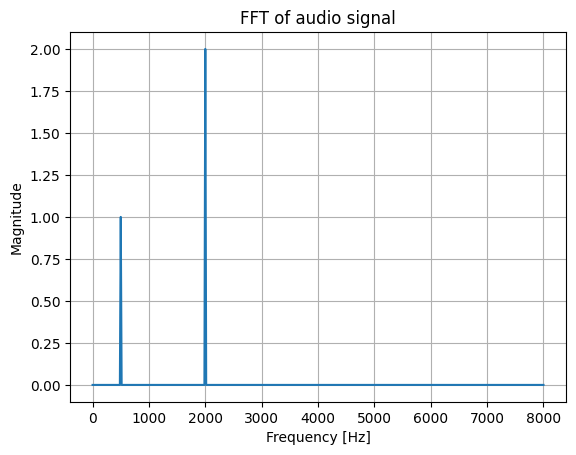

In [6]:
t_axis = np.arange(0, duration, 1/fs)    

audio_time = np.zeros(len(t_axis))

for idx, freq in enumerate(audio_freq):
    if len(audio_amp) == 1:
        # all the parts of the signal have the same frequency
        audio_time += audio_amp * np.sin(2 * np.pi * freq * t_axis  + audio_phase)
    else:
        audio_time += audio_amp[idx] * np.sin(2 * np.pi * freq * t_axis  + audio_phase[idx])

# The frequencies of the signal (division of nfft/2 for the magnitude to be correct)
audio_fft = np.fft.rfft(audio_time, n=nfft) 

plt.plot(t_axis[:int(0.01 * fs)]*1_000, audio_time[:int(0.01 * fs)])
plt.xlabel("Time [ms]")
plt.ylabel("Magnitude")
plt.title("The Audio Signal")
plt.grid(True)
plt.show()

plt.plot(f_axis, np.abs(audio_fft)/(nfft/2))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("FFT of audio signal")
plt.grid(True)
plt.show()

## The Sound Zones
### Defining the Bright and Dark Zones

In [7]:
# Some needed contants
c = pra.constants.get('c')          # Speed of sound

energy_tot = 0

# Define the centers and radius for the circular zones
radius = 0.5
bright_center = np.array([1.5, 3.0, 2.5])
dark_center = np.array([3.5, 3.0, 2.5])
dist_to_bright = np.sqrt((mics_locs[0, :] - bright_center[0])**2 + (mics_locs[1, :] - bright_center[1])**2 + (mics_locs[2, :] - bright_center[2])**2)
dist_to_dark = np.sqrt((mics_locs[0, :] - dark_center[0])**2 + (mics_locs[1, :] - dark_center[1])**2 + (mics_locs[2, :] - dark_center[2])**2)
bright_indices = np.where(dist_to_bright <= radius)[0]
dark_indices = np.where(dist_to_dark <= radius)[0]

### Calculating $p=Hg$ for each frequency

In [8]:
# To save all pressure values of all microphones
p_full = np.zeros((num_mics,     nfft//2 + 1), dtype=complex)
g_full = np.zeros((num_speakers, nfft//2 + 1), dtype=complex)

for idx, f in enumerate(f_axis):

    # Computing the wave number
    k = 2 * np.pi * f / c   
 
    H = H_full[:, :, idx]
    
    Hb = H[bright_indices, :]
    Hd = H[dark_indices, :]

    # The ACC Math
    lambda_reg = 1e-2 # Regularization to limit "array effort"
    R_dark = Hd.conj().T @ Hd + lambda_reg * np.eye(num_speakers)
    R_bright = Hb.conj().T @ Hb

    # Find the eigenvectors, optimal weights are the eigenvector corresponding to the largest eigenvalue
    vals, vecs = eig(R_bright, R_dark)
    optimal_g = vecs[:, np.argmax(np.real(vals))]

    # Multiply the transfer functions by our optimal speaker weights
    p = H @ optimal_g

    p_full[:, idx] = p
    g_full[:, idx] = optimal_g

    energy_tot += np.abs(p)**2      # Needed for plotting later

p_total_rms = np.sqrt(energy_tot)


### Plotting the sound field of the room

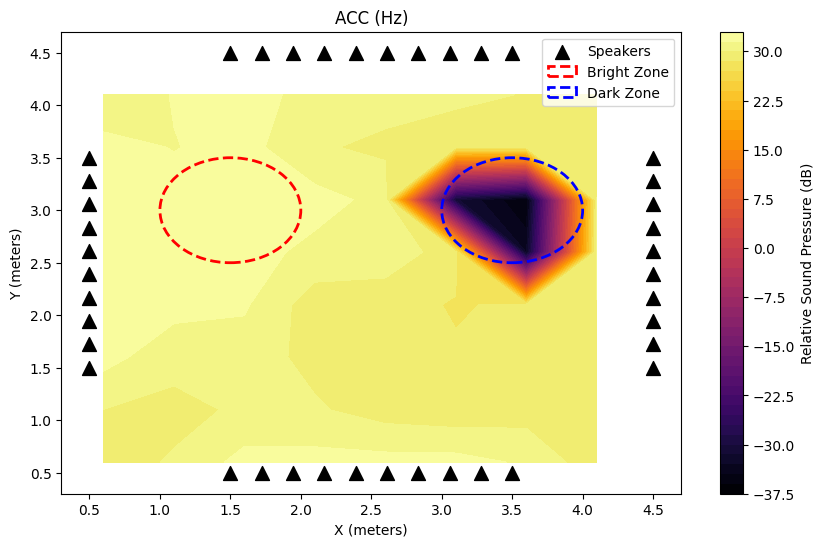

In [9]:
# Reshape for the plot
pressure_map = p_total_rms.reshape(X.shape)

# Plotting
plt.figure(figsize=(10, 6))
plt.contourf(X, Y, 20 * np.log10(pressure_map.clip(-80, 40)), levels=50, cmap='inferno')
plt.colorbar(label="Relative Sound Pressure (dB)")

# Overlay speakers and the zone boundary
plt.scatter(all_speakers[0, :], all_speakers[1, :], color='black', label='Speakers', marker='^', s=100)

# Draw the Bright Zone circle (Left)
bright_circle = plt.Circle(bright_center, radius, color='red', fill=False, linestyle='--', linewidth=2, label='Bright Zone')
plt.gca().add_patch(bright_circle)

# Draw the Dark Zone circle (Right)
dark_circle = plt.Circle(dark_center, radius, color='blue', fill=False, linestyle='--', linewidth=2, label='Dark Zone')
plt.gca().add_patch(dark_circle)

# plt.axvline(2.5, color='black', linestyle='--', label='Zone Boundary')

plt.title(f"ACC (Hz)")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.legend()
plt.show()

### Visualizing the numbering of the microphones

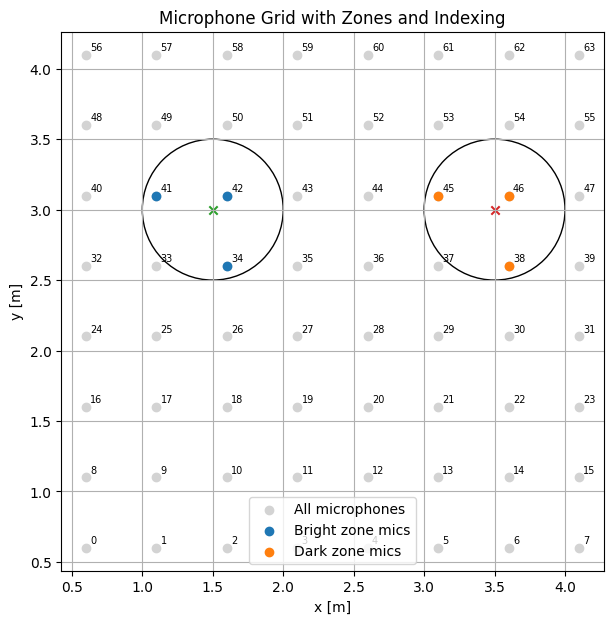

In [10]:
import matplotlib.pyplot as plt
import numpy as np

x = mics_locs[0, :]
y = mics_locs[1, :]

plt.figure(figsize=(7,7))

# Alla mikrofoner
plt.scatter(x, y, color='lightgray', label='All microphones')

# Numrering
for i in range(num_mics):
    plt.text(x[i] + 0.03, y[i] + 0.03, str(i), fontsize=7)

# Bright zone
plt.scatter(x[bright_indices], y[bright_indices],
            label='Bright zone mics')

# Dark zone
plt.scatter(x[dark_indices], y[dark_indices],
            label='Dark zone mics')

# Rita cirklar
bright_circle = plt.Circle(bright_center[:2], radius, fill=False)
dark_circle = plt.Circle(dark_center[:2], radius, fill=False)

plt.gca().add_patch(bright_circle)
plt.gca().add_patch(dark_circle)

# Markera centrum
plt.scatter(bright_center[0], bright_center[1], marker='x')
plt.scatter(dark_center[0], dark_center[1], marker='x')

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Microphone Grid with Zones and Indexing")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

## Listen to the Example

In [11]:
# Create a fresh room just for listening (saves memory/time)
# We use the same dimensions and properties as your original room
listening_room = pra.ShoeBox(room_dim, fs=fs, max_order=nbr_bounces, air_absorption=air_absorption)

# 3. Generate and add the speaker signals using optimal_g
for i in range(num_speakers):

    g = p_full[i, :]
    
    # Extract volume (magnitude) and delay (phase) from the complex weight
    g_mag = np.abs(g)
    g_phase = np.angle(g)

    audio_mag = np.abs(audio_fft)
    audio_phase = np.angle(audio_fft)

    # Create the time-domain sine wave for this specific speaker
    speaker_signal = np.zeros(len(t_axis))
    for ii, freq in enumerate(f_axis):
        speaker_signal += g_mag[ii] * audio_mag[ii] * np.sin(2 * np.pi * freq * t_axis + audio_phase[ii] + g_phase[ii])
    
    # Add the speaker to the new room at the original coordinates
    listening_room.add_source(all_speakers[:, i], signal=speaker_signal)

# 4. Place exactly TWO microphones (The listening points)
# Mic 0 is Bright Center, Mic 1 is Dark Center
listening_mics = np.vstack((bright_center[0], bright_center[1], 2.5))
listening_mics = np.hstack((listening_mics, [[dark_center[0]], [dark_center[1]], [2.5]]))

listening_room.add_microphone_array(pra.MicrophoneArray(listening_mics, listening_room.fs))

# 5. Run the Simulation
print("Simulating audio for playback...")
listening_room.simulate()

# 6. Extract the audio signals
# The signals are usually very quiet or very loud depending on the math, 
# so we normalize them to standard audio levels (-1.0 to 1.0) before saving
bright_audio = listening_room.mic_array.signals[0, :]
dark_audio = listening_room.mic_array.signals[1, :]

# Find the maximum peak across BOTH signals to preserve their relative volume difference
max_val = max(np.max(np.abs(bright_audio)), np.max(np.abs(dark_audio)))
bright_audio_norm = bright_audio / max_val
dark_audio_norm = dark_audio / max_val

# Convert to 16-bit PCM WAV format
bright_wav = np.int16(bright_audio_norm * 32767)
dark_wav = np.int16(dark_audio_norm * 32767)

# 7. Save the files to your current directory
wav.write("bright_zone_center.wav", fs, bright_wav)
wav.write("dark_zone_center.wav", fs, dark_wav)

print("Audio files saved! Go listen to them.")

Simulating audio for playback...
Audio files saved! Go listen to them.
